In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import torch
import torch.nn as nn
import os
import numpy as np

os.chdir("/Users/shanewarland/Desktop/transformer-from-scratch/notebooks")
os.getcwd()

'/Users/shanewarland/Desktop/transformer-from-scratch/notebooks'

In [15]:
from src.dataset import DNADataset
from torch.utils.data import DataLoader
sequences = ['ACGT', 'AACC', 'ATCC', 'AGAG']
labels = [0,1,0,1]
dataset = DNADataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
X, y = next(iter(dataloader))
print(X.shape)
print(y.shape)

torch.Size([2, 4])
torch.Size([2, 1])


In [273]:
import torch
import torch.nn as nn

from src.positional_encoding import PositionalEncoding
from src.transformer_encoder import TransformerEncoder
from src.dna_transformer import DNATransformer

model = DNATransformer(vocab_size=6,d_model=8,num_heads=2,d_ff=32,num_layers=3,max_len=101)
logits, layer_weights = model(X)

In [17]:
criterion = torch.nn.BCEWithLogitsLoss()
loss = criterion(logits, y)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
loss.backward()
optimizer.step()
print(logits.shape)
print(y.shape)
print(loss)
print(model.classifier.weight.grad)
print(model.classifier.weight.grad.shape)

torch.Size([2, 1])
torch.Size([2, 1])
tensor(0.2927, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor([[ 0.3044, -0.1335,  0.0107,  0.2368, -0.1242,  0.1719, -0.1286, -0.3375]])
torch.Size([1, 8])


In [274]:
from src.dataset import DNADataset
from torch.utils.data import DataLoader
sequences = ['ACGT', 'AACC', 'ATCC', 'AGAG']
labels = [0,1,0,1]
dataset = DNADataset(sequences, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
model = DNATransformer(vocab_size=6,d_model=8,num_heads=2,d_ff=32,num_layers=3,max_len=101)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
epochs = 10
logits_list = []
for epoch in range(epochs):
    model.train()  
    running_train_loss = 0.0

    for X, y in dataloader:
        
        optimizer.zero_grad()
        logits, _ = model(X)
        print(logits.shape)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        print(loss.item())
        running_train_loss += loss.item()
        logits_list.append(logits)

    epoch_train_loss = running_train_loss / len(dataloader)
    print('epoch num:', epoch, epoch_train_loss)


  

torch.Size([2, 1])
0.6982969641685486
torch.Size([2, 1])
0.6954184770584106
epoch num: 0 0.6968577206134796
torch.Size([2, 1])
0.6884344220161438
torch.Size([2, 1])
0.7010200619697571
epoch num: 1 0.6947272419929504
torch.Size([2, 1])
0.6954139471054077
torch.Size([2, 1])
0.6988047957420349
epoch num: 2 0.6971093714237213
torch.Size([2, 1])
0.6812468767166138
torch.Size([2, 1])
0.7021398544311523
epoch num: 3 0.6916933655738831
torch.Size([2, 1])
0.6989277601242065
torch.Size([2, 1])
0.6826860308647156
epoch num: 4 0.6908068954944611
torch.Size([2, 1])
0.6873108744621277
torch.Size([2, 1])
0.6889729499816895
epoch num: 5 0.6881419122219086
torch.Size([2, 1])
0.6999250054359436
torch.Size([2, 1])
0.666379451751709
epoch num: 6 0.6831522285938263
torch.Size([2, 1])
0.6882471442222595
torch.Size([2, 1])
0.6791907548904419
epoch num: 7 0.6837189495563507
torch.Size([2, 1])
0.6902462244033813
torch.Size([2, 1])
0.6693189144134521
epoch num: 8 0.6797825694084167
torch.Size([2, 1])
0.69857037

In [179]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [268]:
from src.synthetic_data import generate_synthetic_dna_scramble_motif, generate_synthetic_dna_with_motif, create_combined_dataset

motif = "TATAAA"
scramble_motif = "AAATAT"
negatives = generate_synthetic_dna_scramble_motif(100, 100, motif, scramble_motif)
positives = generate_synthetic_dna_with_motif(100, 100, motif)
sequences, labels = create_combined_dataset(negatives, positives)
assert len(sequences) == 100
assert len(labels) == 100
assert sum(labels) == 50
assert len(motif) == len(scramble_motif)

for seq, label in zip(sequences, labels):
    if label == 0:
        assert motif not in seq
    else:
        assert motif in seq

In [269]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(sequences, labels, test_size = 0.2, stratify = labels, random_state = 42)

train_dataset = DNADataset(X_train, y_train)
val_dataset = DNADataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Now lets add the CNN tran/val loader

In [182]:
from src.dna_cnn import DNACNN
cnn_train_dataset = DNADataset(X_train, y_train, add_cls=False)
cnn_val_dataset = DNADataset(X_val, y_val, add_cls=False)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=32,
    shuffle=True
)
cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=32,
    shuffle=False
)

cnn_model = DNACNN(
    vocab_size=5,
    embedding_dim=8,
    num_filters=16,
    kernel_size=6
)

In [275]:

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
epochs = 50
history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

for epoch in range(epochs):
    model.train()  
    running_train_loss = 0.0

    for X, y in train_loader:
        
        optimizer.zero_grad()
        logits, _ = model(X)
        

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()


        ## now for evaluation
    model.eval()
    ## Initialize variables
    running_val_loss = 0.0
    ## No longer update gradients
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in val_loader:
            
            ## Get predictions
            logits, _ = model(X)
            ## Calculate Loss
            loss = criterion(logits, y)
            running_val_loss += loss.item()

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5)
            correct += (predictions.float() == y).sum().item()
            total += len(y)



    epoch_val_loss = running_val_loss / len(val_loader)
    history["validation_loss"].append(epoch_val_loss)
    validation_accuracy = correct/total
    history["validation_accuracy"].append(validation_accuracy)
    epoch_train_loss = running_train_loss / len(train_loader)
    history["train_loss"].append(epoch_train_loss)
    print(
    f"Epoch {epoch + 1}: "
    f"train={epoch_train_loss:.4f}, "
    f"val={epoch_val_loss:.4f}", f"val_acc={validation_accuracy:.4f}")


Epoch 1: train=0.7036, val=0.6965 val_acc=0.5000
Epoch 2: train=0.6942, val=0.6953 val_acc=0.5000
Epoch 3: train=0.6938, val=0.6949 val_acc=0.4500
Epoch 4: train=0.6934, val=0.6948 val_acc=0.4500
Epoch 5: train=0.6930, val=0.6947 val_acc=0.5000
Epoch 6: train=0.6927, val=0.6947 val_acc=0.5000
Epoch 7: train=0.6931, val=0.6949 val_acc=0.5000
Epoch 8: train=0.6930, val=0.6950 val_acc=0.5000
Epoch 9: train=0.6966, val=0.6950 val_acc=0.5000
Epoch 10: train=0.6935, val=0.6945 val_acc=0.5000
Epoch 11: train=0.6930, val=0.6944 val_acc=0.5000
Epoch 12: train=0.6937, val=0.6943 val_acc=0.5000
Epoch 13: train=0.6930, val=0.6943 val_acc=0.5000
Epoch 14: train=0.6933, val=0.6944 val_acc=0.5000
Epoch 15: train=0.6941, val=0.6945 val_acc=0.5000
Epoch 16: train=0.6971, val=0.6944 val_acc=0.5000
Epoch 17: train=0.6933, val=0.6941 val_acc=0.5000
Epoch 18: train=0.6936, val=0.6939 val_acc=0.4000
Epoch 19: train=0.6928, val=0.6939 val_acc=0.5000
Epoch 20: train=0.6931, val=0.6938 val_acc=0.5000
Epoch 21:

In [211]:
test_X = generate_synthetic_dna_with_motif(2, 100, motif)

test_dataset = DNADataset(test_X, [1])

X, y = test_dataset[0]

print(X.shape)
X = X.unsqueeze(0)
print(X.shape)

model.eval()

with torch.no_grad():
    logits, layer_weights = model(X)

for weights in layer_weights:
    print(weights.shape)


torch.Size([101])
torch.Size([1, 101])
torch.Size([1, 2, 101, 101])
torch.Size([1, 2, 101, 101])
torch.Size([1, 2, 101, 101])


for each of your 3 layers × 2 heads, extract the CLS row and ask where its largest attention weights occur. Then we can compare those positions with TATAAA.

In [230]:
motif_count = 0
pos_idx = 75
for weights in layer_weights:
    for head in range(2):
        cls = weights[0,head,0,:]
        idx = torch.argmax(cls) 
        if idx.item() in range(pos_idx +1, pos_idx + 7):
            motif_count +=1
print( motif_count)




1


In [ ]:
test_X[0].index('TATAAA')
#75

75

In [260]:
#100 positive sequences
test_X = generate_synthetic_dna_with_motif(200, 100, motif)
test_y = 100 * [1]
test_dataset = DNADataset(test_X, test_y)
motif_count_list = []
for i in range(100):
    X, y = test_dataset[i]
    X = X.unsqueeze(0)

    model.eval()

    with torch.no_grad():
        logits, layer_weights = model(X)

    ## get index of 'TATAAA'
    pos_idx = test_X[i].index('TATAAA')

    ## see if any of the CLS layer maxs overlap with the position index

    for index, weights in enumerate(layer_weights):
        motif_count = 0
        for head in range(2):
            cls = weights[0,head,0,:]
            idx = torch.argmax(cls) 
            hit = 0
            if idx.item() in range(pos_idx +1, pos_idx + 7):
                hit = 1
            append_list = [index, head, hit]
    
            motif_count_list.append(append_list)


motif_count_list

[[0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 1],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 1],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 1],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 1],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 0],
 [2, 0, 1],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 1],
 [2, 0, 1],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 0],
 [2, 0, 0],
 [2, 1, 0],
 [0, 0, 0],
 [0, 1, 0],
 [1, 0, 0],
 [1, 1, 1],
 [2, 0, 0],
 [2,

In [261]:
motif_count_list

import pandas as pd

df = pd.DataFrame(motif_count_list, columns=['key1', 'key2', 'val3'])

# Group, sum, and divide by 100
result = (df.groupby(['key1', 'key2'])['val3'].sum() / 100).to_dict()

print(result)

{(0, 0): 0.01, (0, 1): 0.08, (1, 0): 0.03, (1, 1): 0.09, (2, 0): 0.07, (2, 1): 0.04}


lets try it for my CNN model

In [ ]:

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=0.001)
    
epochs = 50
cnn_history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
}

for epoch in range(epochs):
    cnn_model.train()  
    running_train_loss = 0.0

    for X, y in cnn_train_loader:
        
        optimizer.zero_grad()
        logits = cnn_model(X)
        

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()


        ## now for evaluation
    cnn_model.eval()
    ## Initialize variables
    running_val_loss = 0.0
    ## No longer update gradients
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in cnn_val_loader:
            
            ## Get predictions
            logits = cnn_model(X)
            ## Calculate Loss
            loss = criterion(logits, y)
            running_val_loss += loss.item()

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5)
            correct += (predictions.float() == y).sum().item()
            total += len(y)



    epoch_val_loss = running_val_loss / len(cnn_val_loader)
    cnn_history["validation_loss"].append(epoch_val_loss)
    validation_accuracy = correct/total
    cnn_history["validation_accuracy"].append(validation_accuracy)
    epoch_train_loss = running_train_loss / len(cnn_train_loader)
    cnn_history["train_loss"].append(epoch_train_loss)
    print(
    f"Epoch {epoch + 1}: "
    f"train={epoch_train_loss:.4f}, "
    f"val={epoch_val_loss:.4f}", f"val_acc={validation_accuracy:.4f}")

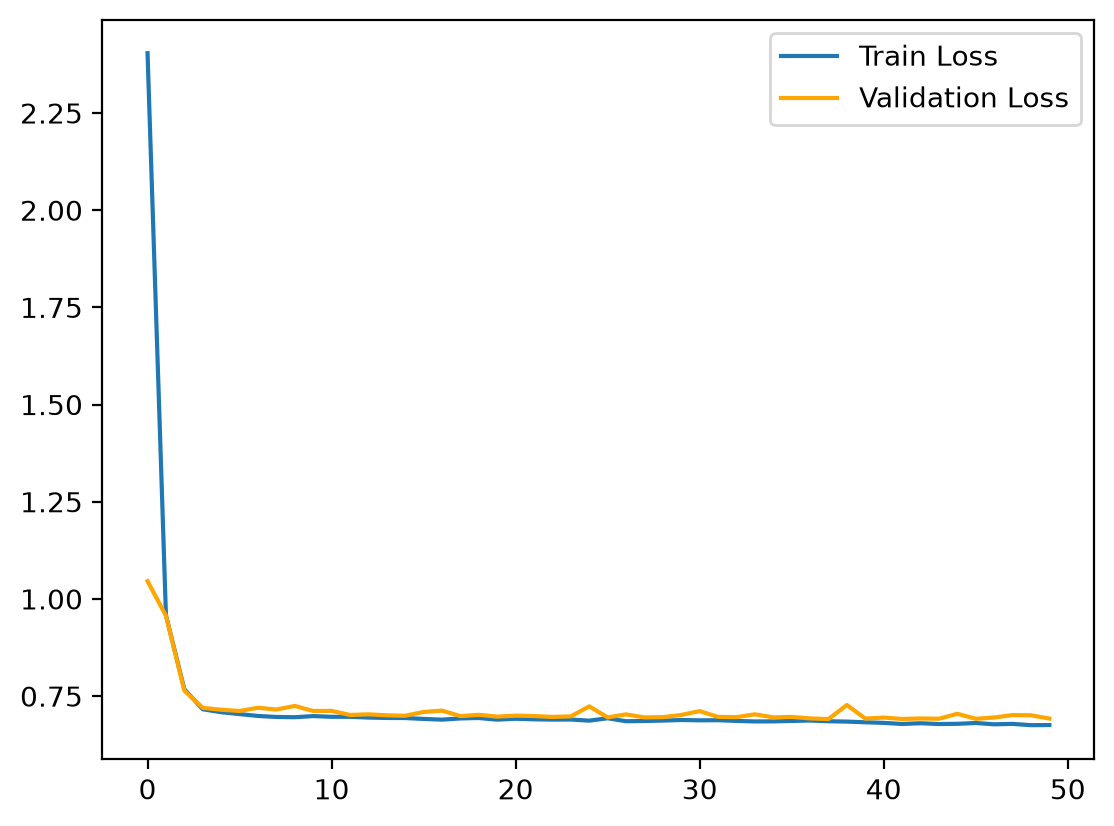

In [129]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['validation_loss'], color = 'orange', label='Validation Loss')
plt.legend()
plt.legend()

In [130]:
positive_idx = y_val.index(1)
sequence = X_val[positive_idx]

print(sequence)
print(sequence.find("TATAAA"))

GGTGTGAACGGTTAGTTAGGCCACTCATATTTGAATGAATTATAAAAAGCAGGCACATCCAAGGCGGGGCGCCTTCGCATTAACAGCGGTCCGGCGAGAT
40


In [ ]:
try_dataset = DNADataset([sequence] , [1],  add_cls=False)
try_loader = DataLoader(try_dataset, batch_size=32, shuffle=True)

X, y = next(iter(try_loader))
#cnn_model = DNACNN(vocab_size=5,embedding_dim=8,num_filters=16,kernel_size=6)

X = cnn_model.embedding(X)
X = X.transpose(1, 2)
X = cnn_model.conv(X)
X = torch.relu(X)
X.shape
activations = X
max_values, max_positions = torch.max(activations, dim=2)

print(max_values)
print(max_positions)

tensor([[ 0.2688,  5.5429,  5.9820, 11.3823,  6.2161,  5.4670,  5.7656, 13.7694,
          5.0714,  6.0817,  6.1529,  7.1613,  5.2187,  3.1324,  0.6325,  0.6424]],
       grad_fn=<MaxBackward0>)
tensor([[26, 29, 41, 38, 41, 25, 16, 40, 28, 39, 39, 16,  7, 38, 14, 37]])


In [163]:
max_positions.shape

torch.Size([32, 16])

In [149]:
for filter_idx, pos in enumerate(max_positions[0]):
    pos = pos.item()

    print(
        filter_idx,
        f"{max_values[0, filter_idx].item():.2f}",
        pos,
        sequence[pos:pos+6]
    )

0 0.27 26 ATATTT
1 5.54 29 TTTGAA
2 5.98 41 ATAAAA
3 11.38 38 ATTATA
4 6.22 41 ATAAAA
5 5.47 25 CATATT
6 5.77 16 TAGGCC
7 13.77 40 TATAAA
8 5.07 28 ATTTGA
9 6.08 39 TTATAA
10 6.15 39 TTATAA
11 7.16 16 TAGGCC
12 5.22 7 ACGGTT
13 3.13 38 ATTATA
14 0.63 14 GTTAGG
15 0.64 37 AATTAT


In [166]:
val_sequences = generate_synthetic_dna_with_motif(100, 100, 'TATAAA')
val_labels = 50 * [1]
try_dataset = DNADataset(val_sequences , val_labels,  add_cls=False)
try_loader = DataLoader(try_dataset, batch_size=32, shuffle=False)

filter_seven_ct = 0
sequence_index = 0

for X, y in try_loader:

    X = cnn_model.embedding(X)
    X = X.transpose(1, 2)
    X = cnn_model.conv(X)
    activations = torch.relu(X)

    max_values, max_positions = torch.max(activations, dim=2)

    filter_seven_positions = max_positions[:, 7]
    for pos in filter_seven_positions:
        if val_sequences[sequence_index][pos:pos+6] == 'TATAAA':
            filter_seven_ct +=1
        sequence_index+=1

print(filter_seven_ct / 50)



1.0


In [168]:
val_sequences = generate_synthetic_dna_scramble_motif(100, 100, 'TATAAA', "AAATAT")
val_labels = 50 * [0]
try_dataset = DNADataset(val_sequences , val_labels,  add_cls=False)
try_loader = DataLoader(try_dataset, batch_size=32, shuffle=False)

filter_seven_ct = 0
sequence_index = 0

for X, y in try_loader:

    X = cnn_model.embedding(X)
    X = X.transpose(1, 2)
    X = cnn_model.conv(X)
    activations = torch.relu(X)

    max_values, max_positions = torch.max(activations, dim=2)

    filter_seven_positions = max_positions[:, 7]
    for pos in filter_seven_positions:
        if val_sequences[sequence_index][pos:pos+6] == 'TATAAA':
            filter_seven_ct +=1
        sequence_index+=1

print(filter_seven_ct / 50)

0.0


For L = 4, create a PyTorch tensor that produces:

[[ 0,  1,  2,  3],
 [-1,  0,  1,  2],
 [-2, -1,  0,  1],
 [-3, -2, -1,  0]]

In [316]:
L=4
num_heads=2
positions = torch.arange(L)
print(positions.unsqueeze(0))
print(positions.unsqueeze(0).shape)

print(positions.unsqueeze(1))
print(positions.unsqueeze(1).shape)
relative_positions = positions.unsqueeze(0) - positions.unsqueeze(1)

relative_positions = relative_positions + (L - 1)

bias_lookup = nn.Embedding(
    num_embeddings=2 * L - 1,
    embedding_dim=num_heads
)

relative_bias = bias_lookup(relative_positions).squeeze(-1)
relative_bias = relative_bias.permute(2, 0, 1)

relative_bias.shape

tensor([[0, 1, 2, 3]])
torch.Size([1, 4])
tensor([[0],
        [1],
        [2],
        [3]])
torch.Size([4, 1])


torch.Size([2, 4, 4])

In [311]:
attention = MultiHeadSelfAttention(
    d_model=8,
    num_heads=2,
    max_len=10
)

L = 4
positions = torch.arange(L)

relative_positions = (
    positions.unsqueeze(0)
    - positions.unsqueeze(1)
)

relative_indices = relative_positions + (attention.max_len - 1)

bias = attention.relative_bias(relative_indices)

In [ ]:
print(relative_positions)
print(relative_indices)
print(bias.shape)
assert bias[0, 1, 0] == bias[1, 2, 0] == bias[2, 3, 0]


tensor([[3, 4, 5, 6],
        [2, 3, 4, 5],
        [1, 2, 3, 4],
        [0, 1, 2, 3]])
tensor([[ 9, 10, 11, 12],
        [ 8,  9, 10, 11],
        [ 7,  8,  9, 10],
        [ 6,  7,  8,  9]])
torch.Size([4, 4, 2])


tensor(10)

In [310]:
X.shape

torch.Size([20, 101])

In [299]:
(positions.unsqueeze(0) - positions.unsqueeze(1)).argmax().item()

3